In [130]:
using CSV, DataFrames
using Plots
using Dates
using BenchmarkTools
using JuMP, HiGHS

## Optimization model for storage system scheduling - LP relaxation

In [131]:
function schedule_opt(t_set, soe_min, soe_max, p_c_max, p_d_max, prices, ρ, η_c, η_d, soe_init, test_simult)
    model = Model(HiGHS.Optimizer)
    nb_t = length(t_set)

    @variables model begin
            soe_min <= soe[t in 1:nb_t] <= soe_max
            0 <= p_c[t in 1:nb_t] <= p_c_max
            0 <= p_d[t in 1:nb_t] <= p_d_max
        end

    @objective(model, Max, sum(prices[t]*(p_d[t]-p_c[t]) for t in 1:nb_t))

    @constraints model begin
        StorageBalance[t in 2:nb_t],
            soe[t] == ρ * soe[t-1] + η_c * p_c[t] - (1/η_d) * p_d[t]
        StorageBalance_init,
            soe[1] == ρ * soe_init + η_c * p_c[1] - (1/η_d) * p_d[1]
    end
    if test_simult >= 1
        @constraint(model, p_d[test_simult]==0.2)
    end

    set_silent(model)
    optimize!(model)
    println(termination_status(model))

    soe_val=[]
    charge=[]
    discharge=[]
    profit_cumul_old = 0
    for t in 1:nb_t
        append!(charge,JuMP.value.(p_c[t]))
        append!(discharge,JuMP.value.(p_d[t]))
        append!(soe_val,JuMP.value.(soe[t]))
    end
    obj = JuMP.objective_value(model)

    return soe_val, obj, charge, discharge
end
;

## Examples Section 3.3

### Figure 2.a: Positive prices, simultaneous charge and discharge

In [132]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 1.5 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 26th May 2023
t_start = 3480
t_end = 3503
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = 15 # force discharge at time period 15
;

In [133]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 131.76€


In [134]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

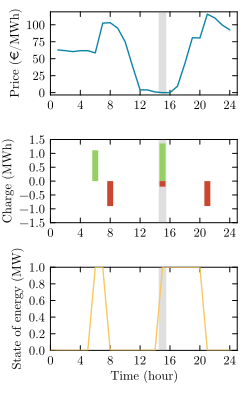

In [135]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [136]:
savefig("Figure_2_a.pdf");

### Figure 2.b: Positive prices, no simultaneous charge and discharge

In [137]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0
soe_max = 1
soe_init = 0.0
η_c = 0.9
η_d = 0.9
p_c_max = 1.5                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
p_d_max = p_c_max
ρ = 1
# 26th May 2023
t_start = 3480
t_end = 3503
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [138]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 131.76€


In [139]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[14.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

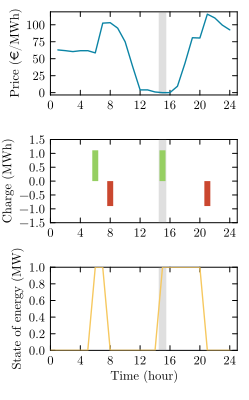

In [140]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [141]:
savefig("Figure_2_b.pdf");

### Figure 3.a: Negative prices, no inefficiencies

In [142]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 1
η_d = 1
p_c_max = 0.6 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [143]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 84.14€


In [144]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

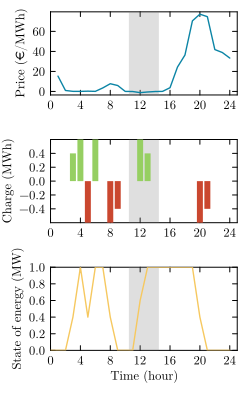

In [145]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [146]:
savefig("Figure_3_a.pdf");

### Figure 3.b: Negative prices, inefficiencies

In [147]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.6 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [148]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 76.12€


In [149]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

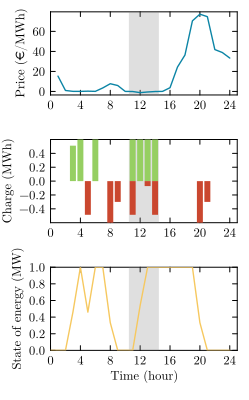

In [150]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [151]:
savefig("Figure_3_b.pdf");

### Figure 3.c: Negative prices, inefficiencies, slow

In [152]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.2 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [153]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 60.43€


In [154]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

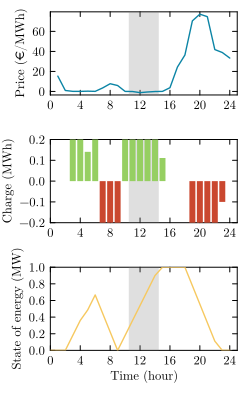

In [155]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [156]:
savefig("Figure_3_c.pdf");

## Examples Section 4.2.2

### Figure 4.a: Fast storage

In [157]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 2.0 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 1st January 2023
t_start = 1
t_end = 24
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [158]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 51.22€


In [159]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

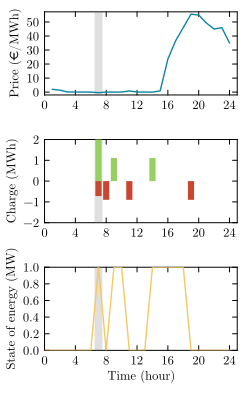

In [160]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

*Results here might look different to the ones in the paper due to solution multiplicity. It is possible to check this by adding the constraint p_d[8]==0, and checking that the profit obtained is the same.*

In [161]:
savefig("Figure_4_a.pdf");

### Figure 4.b: Slow storage

In [162]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.4 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 1st January 2023
t_start = 1
t_end = 24
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [163]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 49.61€


In [164]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[6.5, 7.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

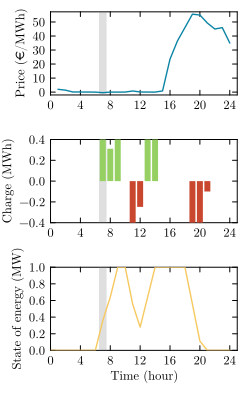

In [165]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

*Results here might look different to the ones in the paper due to solution multiplicity. It is possible to check this by adding the constraint p_c[9]==0, and checking that the profit obtained is the same.*

In [166]:
savefig("Figure_4_b.pdf");

## Examples Section 4.3.2

### Figure 5.a: Simultaneous charge and discharge

In [167]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.036 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 7-9th July 2023
t_start = 5255
t_end = 5286
n_max = 32
T = [t_start:t_end;]
T_plt = [0:t_end-t_start+1;]
test_simult = false
;

In [168]:
# Check system 

model = Model(HiGHS.Optimizer)

@variable(model, n >= 0, Int)
@variable(model, m >= 0, Int)
@variable(model, soe_min <= s <= soe_max)

@objective(model, Max, 1)

@constraint(model, m+n==n_max)
@constraint(model, s + n*η_c * p_c_max - (m/η_d) * p_d_max == soe_max)
@constraint(model, s==soe_init)

set_silent(model)
optimize!(model)
println(termination_status(model))

INFEASIBLE


In [169]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 5.49€


In [170]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

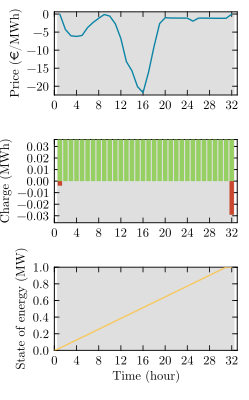

In [171]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [172]:
savefig("Figure_5_a.pdf");

### Figure 5.b: No simultaneous charge and discharge

In [173]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.034 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 7-9th July 2023
t_start = 5255
t_end = 5286
T = [t_start:t_end;]
T_plt = [0:t_end-t_start+1;]
test_simult = false
;

In [174]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 5.19€


In [175]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

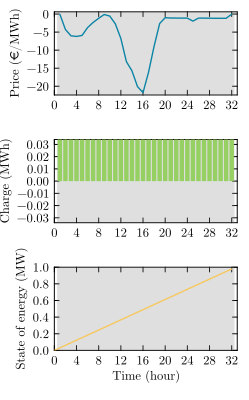

In [176]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [177]:
savefig("Figure_5_b.pdf");

### Figure 6.1: Simultaneous charge and discharge with close blocks

In [178]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.034 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = 0.028 # MW
ρ = 1
# 7-9th July
t_start = 5244
t_end = 5286
T = [t_start:t_end;]
T_plt = [0:t_end-t_start+1;]
test_simult = false
;

In [179]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 6.05€


In [180]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

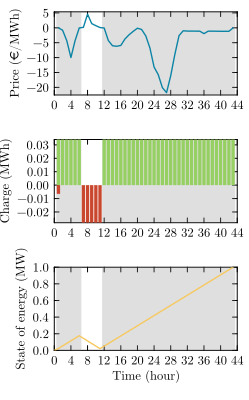

In [181]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [182]:
savefig("Figure_6_a.pdf");

### Figure 5.c: Special case

In [183]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.036 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = 31 *0.81 * p_c_max - 0.9 # MW
ρ = 1
# 7-9th July 2023
t_start = 5255
t_end = 5286
prices[5274,:Price] = -0.01
n_max = 32
T = [t_start:t_end;]
T_plt = [0:t_end-t_start+1;]
test_simult = false
;

In [184]:
p_d_max

0.0039599999999999635

In [185]:
# Check system 

model = Model(HiGHS.Optimizer)

@variable(model, n >= 0, Int)
@variable(model, m >= 0, Int)
@variable(model, soe_min <= s <= soe_max)

@objective(model, Max, 1)

@constraint(model, m+n==n_max)
@constraint(model, s + n*η_c * p_c_max - (m/η_d) * p_d_max == soe_max)
@constraint(model, s==soe_init)

set_silent(model)
optimize!(model)
println(termination_status(model))

OPTIMAL


In [186]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 5.46€


In [187]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,33), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[0.5, 32.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

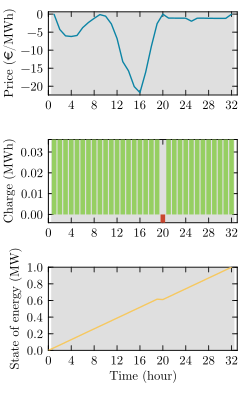

In [188]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [189]:
savefig("Figure_5_c.pdf");

### Figure 6.b: Simultaneous charge and discharge with close blocks

In [190]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.036 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = 31 *0.81 * p_c_max - 0.9 # MW
ρ = 1
# 7-9th July 2023
t_start = 5244
t_end = 5286
prices[5274,:Price] = -0.01
T = [t_start:t_end;]
T_plt = [0:t_end-t_start+1;]
test_simult = false
;

In [191]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 6.18€


In [192]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,T_plt[end]+1), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[11.5, 43.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[0.5, 6.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

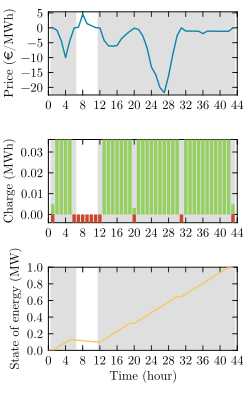

In [193]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [194]:
savefig("Figure_6_b.pdf");

## Example Section 4.4.2

### Figure 7.a: No simultaneous charge and discharge

In [195]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.27 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [196]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 68.82€


In [197]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

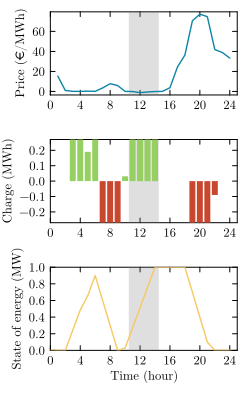

In [198]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [199]:
savefig("Figure_7_a.pdf");

### Figure 7.b: Reaching minimum is not possible

In [200]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 1.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.27 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = 0.08 # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [201]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 35.31€


In [202]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

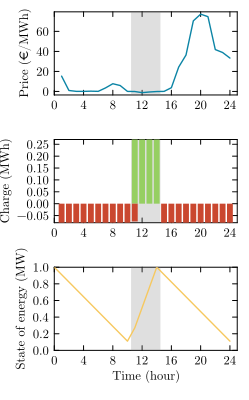

In [203]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [204]:
savefig("Figure_7_b.pdf");

### Figure 7.c: Fast charge

In [205]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 1.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.28 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = 0.27 # MW
ρ = 1
# 25th March 2023
t_start = 1993
t_end = 2016
T = [t_start:t_end;]
T_plt = [0:24;]
test_simult = false
;

In [206]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 73.35€


In [207]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,25), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[10.5, 14.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

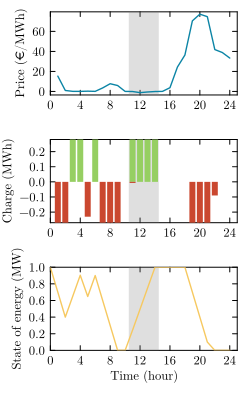

In [208]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(250,400))

In [209]:
savefig("Figure_7_c.pdf");

## Example Section 4.5.2

### Figure 8.a: Fast charge

In [210]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.2 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 27th-29th May 2023
t_start = 3504
t_end = 3575
T = [t_start:t_end;]
T_plt = [0:72;]
test_simult = false
;

In [211]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 397.54€


In [212]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

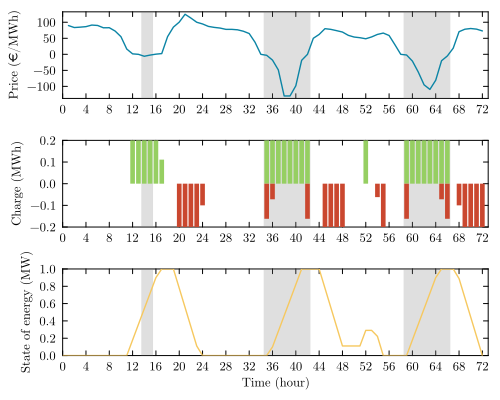

In [213]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(500,400))

In [214]:
savefig("Figure_8_a.pdf");

### Figure 8.b: Slow charge

In [215]:
# Import data
file_name = string("Day-ahead Prices_2023.csv")
prices = DataFrame(CSV.File(file_name; select=["Price"]))

## Parameters
soe_min = 0 # MWh
soe_max = 1 # MWh
soe_init = 0.0 # MWh
η_c = 0.9
η_d = 0.9
p_c_max = 0.1 # MW                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
p_d_max = p_c_max # MW
ρ = 1
# 27th-29th May 2023
t_start = 3504
t_end = 3575
T = [t_start:t_end;]
T_plt = [0:72;]
test_simult = false
;

In [216]:
# Run the optimization
soe_val, profit, charge_val, discharge_val = schedule_opt(T, soe_min, soe_max, p_c_max, p_d_max, prices[T,:Price], ρ, η_c, η_d, soe_init, test_simult)
println("Profit: ", round(profit,digits=2),"€")
# Add initial values for plotting
soe_plt = append!([soe_init],soe_val)
charge_plt = append!([NaN], charge_val)
discharge_plt = append!([NaN], -discharge_val) #  Opposite of discharge to appear as negative on the plots
prices_plt = append!([NaN], prices[T,:Price])
;

OPTIMAL
Profit: 236.1€


In [217]:
## Set-up plot
theme(:dao)
plt_ch_dch = bar(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), ylimits=(-p_d_max,p_c_max), xticks=0:4:72, ylabel = "Charge (MWh)", guidefontsize=8, tickfontsize=8)
plt_price = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), xticks=0:4:72, ylabel = "Price (€/MWh)", guidefontsize=8, tickfontsize=8)
plt_soe = plot(legend=:outerright, grid=:false, minorticks=:false, xlimits=(0,73), ylimits=(0,1), xticks=0:4:72, xlabel="Time (hour)", ylabel = "State of energy (MW)", guidefontsize=8, tickfontsize=8)
# Plot
# Grey areas to identify negative prices
vspan!(plt_price,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[13.5, 15.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[34.5, 42.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)

vspan!(plt_price,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_ch_dch,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
vspan!(plt_soe,[58.5, 66.5], linecolor = :grey, fillcolor = :grey,alpha=0.25)
# Plots
bar!(plt_ch_dch,T_plt,charge_plt, linecolor=nothing, label="Charge (MWh)", color="#96CF62")
bar!(plt_ch_dch,T_plt,discharge_plt, linecolor=nothing, label="Discharge (MWh)", color=:"#CA472F")
plot!(plt_soe,T_plt,soe_plt, label="State of energy (MW)", color="#F6C85F")
plot!(plt_price, T_plt, prices_plt, label="Prices (€/MWh)", color="#0B84A5")
;

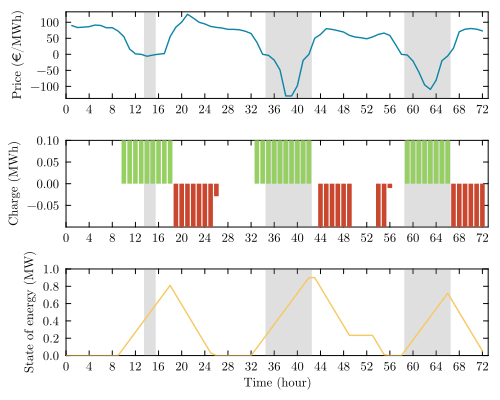

In [218]:
plot(plt_price, plt_ch_dch, plt_soe, layout = (3,1), legend=false, size=(500,400))

In [219]:
savefig("Figure_8_b.pdf");